In [1]:
import os, sys
sys.path.append(os.path.abspath('..'))
print('Project root added:', os.path.abspath('..'))


Project root added: d:\myproject


In [2]:
from backend.ats_score_engine import score_resume_against_job
from backend.resume_feedback_engine import generate_internal_feedback, generate_candidate_feedback


In [3]:
resume_text = '''Python developer with 3+ years of experience in FastAPI, SQL, Docker, AWS, and REST API development. Built backend services, deployed cloud apps, and worked with Git and Linux.'''
job_text = '''Python Backend Developer
Required skills: Python, FastAPI, SQL, Docker, AWS
Preferred skills: REST API, Git, Linux, Microservices
Education: Bachelor's degree in Computer Science or related field
Responsibilities: Build scalable backend systems and deploy APIs to cloud environments.'''


In [4]:
result = score_resume_against_job(parsed_resume=None, parsed_job=None, resume_raw_text=resume_text, job_raw_text=job_text)
print(result.model_dump_json(indent=2))


d:\myproject\myproject\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2855.64it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{
  "ats_score": 62.34,
  "ranking_score": 61.0,
  "match_label": "strong_match",
  "model_name": "Random Forest",
  "class_probabilities": {
    "poor_match": 0.006473,
    "moderate_match": 0.213693,
    "strong_match": 0.779834
  },
  "matched_required_skills": [
    "python",
    "fastapi",
    "sql",
    "docker",
    "aws"
  ],
  "missing_required_skills": [],
  "matched_preferred_skills": [
    "rest api",
    "git",
    "linux"
  ],
  "missing_preferred_skills": [
    "microservices"
  ],
  "matched_keywords": [
    "python",
    "fastapi",
    "sql",
    "docker",
    "aws",
    "rest api",
    "git",
    "linux",
    "backend",
    "rest",
    "api"
  ],
  "missing_keywords": [
    "microservices",
    "education",
    "bachelor",
    "degree",
    "computer",
    "science",
    "related",
    "field",
    "build"
  ],
  "breakdown": {
    "skills": {
      "score": 81.94,
      "summary": "Required-skill coverage, skill-token overlap, and missing-skill penalty.",
      "evid

d:\myproject\myproject\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [5]:
internal_feedback = generate_internal_feedback(None, None, result)
candidate_feedback = generate_candidate_feedback(None, None, result)
print(internal_feedback.model_dump_json(indent=2))
print(candidate_feedback.model_dump_json(indent=2))


{
  "summary": "Candidate classified as strong_match with ATS score 62.34. Ranking score is 61.00 and the strongest evidence comes from skills 81.9, semantic fit 67.8, and keyword coverage 21.2.",
  "match_label": "strong_match",
  "ats_score": 62.34,
  "recommendation": "Prioritize for shortlist or recruiter review.",
  "strengths": [
    "Matched required skills: python, fastapi, sql, docker, aws",
    "Education requirement is satisfied or exceeded.",
    "Model confidence for strong-match class is high."
  ],
  "risks": [
    "Important job keywords are underrepresented in the resume."
  ],
  "reviewer_questions": [
    "Validate recent project depth for the matched core skills.",
    "Confirm role-specific tools mentioned in the resume during screening."
  ],
  "next_actions": [
    "Move to shortlist.",
    "Schedule recruiter call."
  ],
  "evidence": {
    "class_probabilities": {
      "poor_match": 0.006473,
      "moderate_match": 0.213693,
      "strong_match": 0.779834
   

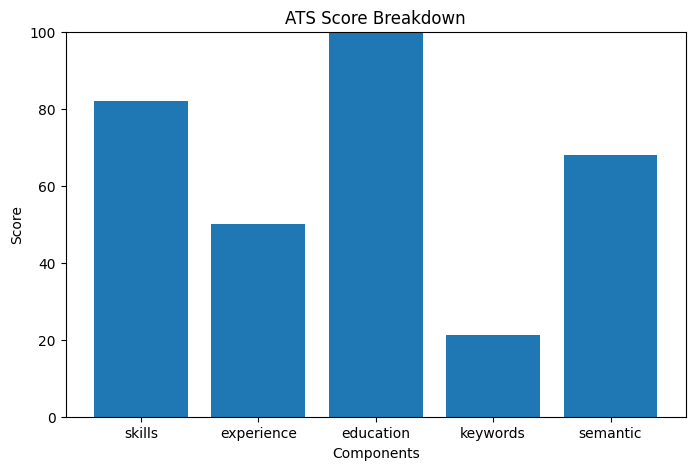

In [6]:
import matplotlib.pyplot as plt
labels = list(result.breakdown.keys())
scores = [comp.score for comp in result.breakdown.values()]
plt.figure(figsize=(8, 5))
plt.bar(labels, scores)
plt.ylim(0, 100)
plt.title('ATS Score Breakdown')
plt.xlabel('Components')
plt.ylabel('Score')
plt.show()
